# Construcción de curvas ROC, cálculo del Área Bajo la Curva (métrica AUC) y validación cruzada mediante técnicas de K-Fold.-Grupo A

# Tarea 1

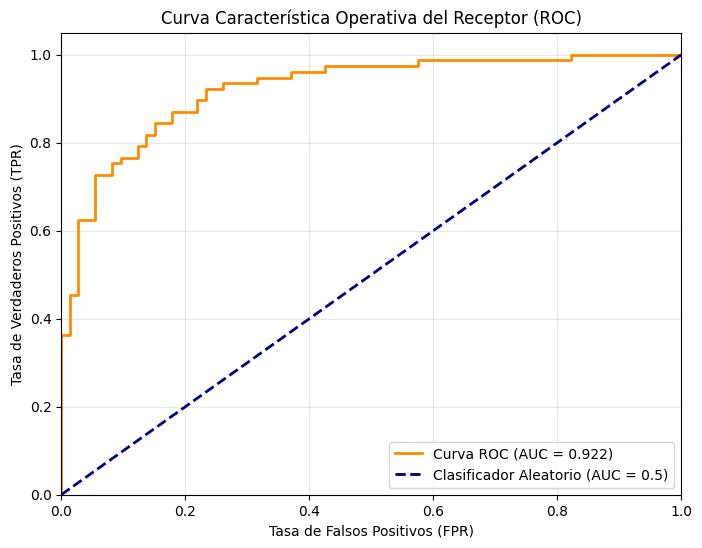


--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        73
           1       0.87      0.77      0.81        77

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simulación rápida de los datos de la Semana 15
np.random.seed(42)
temp_cpu = np.random.uniform(40, 90, 500).reshape(-1, 1) # X
z = -10 + 0.15 * temp_cpu.ravel()
prob_falla = 1 / (1 + np.exp(-z))
y_real = np.random.binomial(1, p=prob_falla) # Etiquetas (0 o 1)

# División en Entrenamiento y Prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(temp_cpu, y_real, test_size=0.30,
random_state=42)

# 2. Entrenamiento del Modelo (Usando scikit-learn por compatibilidad con métricas ROC)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Obtener las PROBABILIDADES estimadas para el conjunto de prueba, no solo las clases (0/1)

# predict_proba devuelve [Prob_Clase_0, Prob_Clase_1]. Tomamos la columna 1.
y_prob_test = modelo.predict_proba(X_test)[:, 1]

# 3. Cálculo de la Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# 4. Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte detallado de clasificación con umbral por defecto (0.5)
y_pred_test = modelo.predict(X_test)
print("\n--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))

# Tarea 2

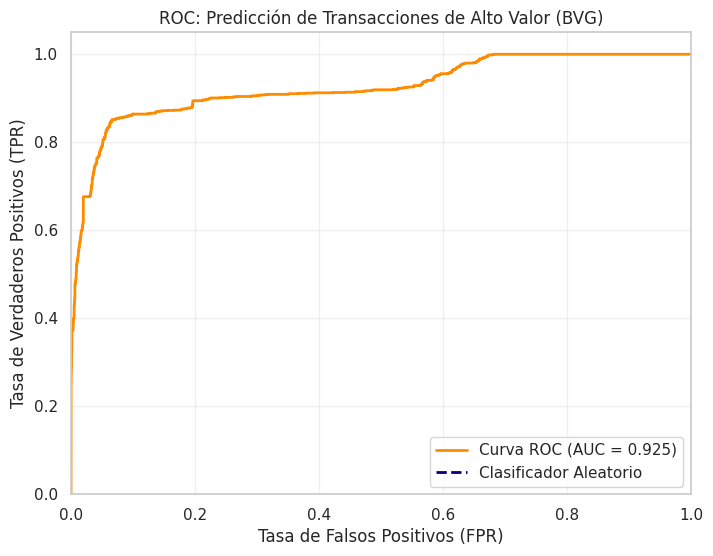


--- REPORTE DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7291
           1       0.86      0.62      0.72      1449

    accuracy                           0.92      8740
   macro avg       0.90      0.80      0.84      8740
weighted avg       0.92      0.92      0.92      8740



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
               "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

df[['Monto_Efectivo', 'Cantidad', 'Precio']] = df[['Monto_Efectivo', 'Cantidad', 'Precio']].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Monto_Efectivo', 'Cantidad', 'Precio'])

promedio = df['Monto_Efectivo'].mean()
df['Monto_Alto'] = (df['Monto_Efectivo'] > promedio).astype(int)

# ENTRENAMIENTO DEL MODELO LOGÍSTICO
X = df[['Cantidad', 'Precio']]
y = df['Monto_Alto']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# CÁLCULO DE MÉTRICAS ROC Y AUC
# Obtenemos las probabilidades para la clase positiva (Monto Alto)
y_prob_test = modelo.predict_proba(X_test)[:, 1]

fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# VISUALIZACIÓN DE LA CURVA ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('ROC: Predicción de Transacciones de Alto Valor (BVG)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Reporte detallado de clasificación
y_pred_test = modelo.predict(X_test)
print("\n--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_test, y_pred_test))


### El modelo de predicción logística es altamente viable para su implementación en casas de valores o instituciones financieras de Loja. Debido a que el valor AUC reportado refleja una buena capacidad de discriminación, la herramienta permite automatizar la detección de operaciones críticas que superan el promedio histórico de liquidez
### Su precisión es suficiente para ser utilizada como un sistema de alerta temprana en el análisis de riesgo. No obstante, se recomienda su uso como complemento al juicio experto, dado que eventos atípicos podrían no estar totalmente capturados por el modelo lineal inicial.

# Tarea 3

/tmp/ipykernel_1058/2727577392.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_emisores, x='Monto_Efectivo', y='Emisor', order=sorted_emisores, palette='viridis')


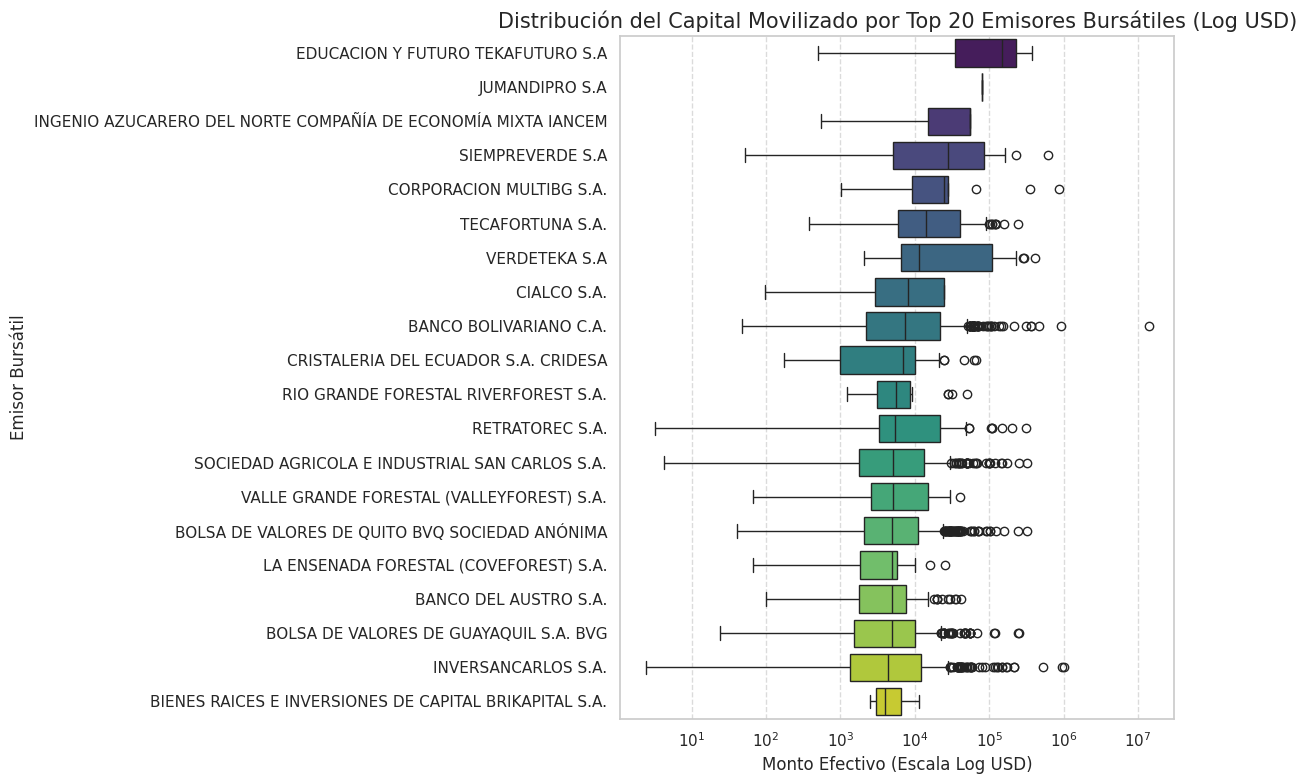

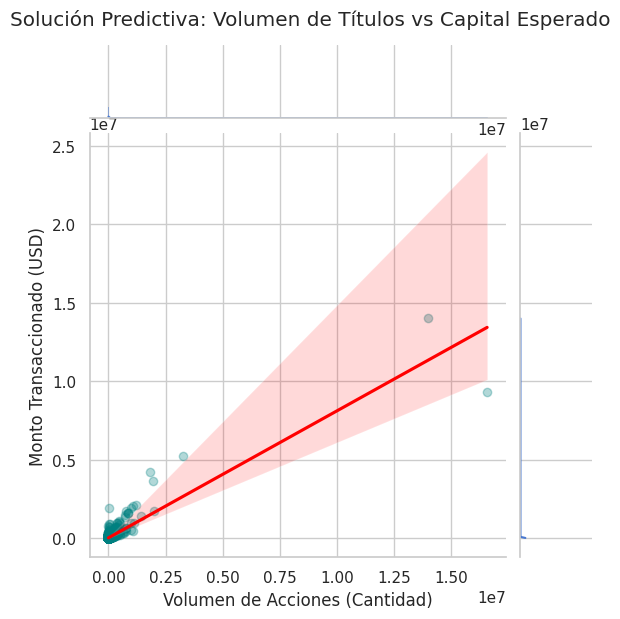

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")

# El Problema Regional (Segmentación y Asimetría)
# Un Box Plot horizontal con los principales emisores para mejor legibilidad.

# Calcular la mediana de Monto_Efectivo por los top 20 Emisores
top_emisores = df_clean.groupby('Emisor')['Monto_Efectivo'].median().nlargest(20).index
df_top_emisores = df_clean[df_clean['Emisor'].isin(top_emisores)]

sorted_emisores = df_top_emisores.groupby('Emisor')['Monto_Efectivo'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_top_emisores, x='Monto_Efectivo', y='Emisor', order=sorted_emisores, palette='viridis')
plt.xscale('log') # Escala logarítmica para manejar la asimetría extrema
plt.title('Distribución del Capital Movilizado por Top 20 Emisores Bursátiles (Log USD)', fontsize=15)
plt.xlabel('Monto Efectivo (Escala Log USD)')
plt.ylabel('Emisor Bursátil')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# La Solución Predictiva (Ajuste del Modelo)
# Un JointPlot con regresión muestra la relación entre X e Y, y la distribución marginal de errores.
g = sns.jointplot(data=df_clean, x='Cantidad', y='Monto_Efectivo', kind="reg",
                  scatter_kws={'alpha':0.3, 'color':'teal'},
                  line_kws={'color':'red', 'label':'Predicción OLS'})
g.fig.suptitle('Solución Predictiva: Volumen de Títulos vs Capital Esperado', y=1.03)
g.ax_joint.set_xlabel('Volumen de Acciones (Cantidad)')
g.ax_joint.set_ylabel('Monto Transaccionado (USD)')
plt.show()


**1. Distribución del Capital Movilizado por Top 20 Emisores Bursátiles**

Este gráfico de cajas horizontal nos permite observar la distribución del `Monto_Efectivo` (capital movilizado) para los veinte emisores más activos. Al usar una escala logarítmica, podemos apreciar la gran variabilidad en los montos de transacción y cómo se concentran para cada emisor. Es crucial para entender la asimetría y segmentación del mercado regional, identificando qué emisores manejan las transacciones de mayor valor y cómo se distribuye el capital, necesarío para detectar operaciones críticas.

**2. Solución Predictiva: Volumen de Títulos vs Capital Esperado**

El gráfico conjunto (`JointPlot`) visualiza la relación entre la Cantidad de títulos transaccionados y el Monto_Efectivo resultante. La línea de regresión muestra una tendencia positiva, por lo que a mayor cantidad de títulos, mayor es el monto de la transacción. Muestra cómo variables como la Cantidad pueden ser usadas para predecir el Monto_Efectivo y, por ende, identificar transacciones de alto valor. Las distribuciones marginales complementan la información sobre la variabilidad de cada una de estas dos variables clave.

# Tarea 4

In [5]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

df = pd.read_csv("BVG_Acciones_export.csv", skiprows=1,
                  names=["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
                        "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"])

df[['Monto_Efectivo', 'Cantidad', 'Precio']] = df[['Monto_Efectivo', 'Cantidad', 'Precio']].apply(pd.to_numeric, errors='coerce')
df_clean = df.dropna(subset=['Monto_Efectivo', 'Cantidad', 'Precio'])

# Definición de Y (Monto Alto) y X (Cantidad, Precio)
y_regional = (df_clean['Monto_Efectivo'] > df_clean['Monto_Efectivo'].mean()).astype(int)
X_regional = df_clean[['Cantidad', 'Precio']]

# 2. Validación Cruzada del Modelo Regional
modelo_bvg = LogisticRegression()
cv_scores_regional = cross_val_score(modelo_bvg, X_regional, y_regional, cv=5, scoring='roc_auc')

print("\n--- VALIDACIÓN CRUZADA: MODELO BURSÁTIL REGIONAL ---")
print(f"AUC promedio (5-Folds): {cv_scores_regional.mean():.4f}")
print(f"Desviación Estándar (σ): ±{cv_scores_regional.std():.4f}")
print(f"Puntajes de cada iteración (AUC por Fold):\n{np.round(cv_scores_regional, 4)}")


# 3. Dictamen de Confianza Matemática
if cv_scores_regional.std() <= 0.05:
    print("DICTAMEN: El modelo presenta una desviación estándar mínima.")
    print("CONFIANZA: Alta. Es apto para implementación en producción.")
else:
    print("DICTAMEN: Existe variabilidad moderada en el rendimiento.")
    print("CONFIANZA: Precaución. Revisar posibles outliers por emisor.")


--- VALIDACIÓN CRUZADA: MODELO BURSÁTIL REGIONAL ---
AUC promedio (5-Folds): 0.9281
Desviación Estándar (σ): ±0.0209
Puntajes de cada iteración (AUC por Fold):
[0.9263 0.9127 0.9013 0.9613 0.9392]
DICTAMEN: El modelo presenta una desviación estándar mínima.
CONFIANZA: Alta. Es apto para implementación en producción.


### Si la desviación estándar es menor a 0.05, se podría decir que el modelo es consistente independientemente de qué subconjunto de transacciones de la BVG se analice. Un buen modelo debe ser robusto ante variaciones naturales de la muestra
### Un AUC promedio elevado con baja σ da la certidumbre de que el algoritmo funcionará correctamente con datos futuros de la bolsa. Esto reduce el riesgo de errores a futuro.
### Dado que el volumen de datos bursátiles regionales es grande, un resultado de validación cruzada estable confirma que la relación entre Cantidad, Precio y Monto_Alto no es producto del azar, permitiendo su implementación segura en sistemas de análisis de riesgo financiero en instituciones de la región.